# Final report figures

This notebook is deliberately **analysis-only**: it reads versioned JSON artifacts from `report/figures/plot_data/`, renders lightweight Matplotlib figures on the login node, and saves each figure as PDF and PNG. It never loads a protein model, samples sequences, or submits a Slurm job.

If the preflight reports absent artifacts, copy the printed `sbatch` command into a terminal and rerun the relevant section after it completes.

In [14]:
%matplotlib inline
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / 'pyproject.toml').exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError('Run from inside the protein-design repository.')

if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from protein_design.analysis import report_data, report_figures
import importlib
report_data = importlib.reload(report_data)
report_figures = importlib.reload(report_figures)

CONFIG = report_data.load_report_config(REPO_ROOT / 'conf/analysis/report_plots.yaml')
FIGURES_DIR = REPO_ROOT / CONFIG['output']['figures_dir']
report_figures.apply_report_style()

def render(plotter, stem, section):
    """Render only when the lightweight JSON inputs are complete."""
    if report_figures.preflight(CONFIG, [section]):
        return None
    fig = plotter(CONFIG)
    pdf, png = report_figures.save_figure(fig, FIGURES_DIR, stem)
    print(f'Saved: {pdf}\nSaved: {png}')
    return fig

print('Repository :', REPO_ROOT)
print('Artifacts :', report_data.data_dir(CONFIG))
print('Figures   :', FIGURES_DIR)

Repository : C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design
Artifacts : C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\plot_data
Figures   : C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures


## Preflight

Check all expected JSON inputs before rendering. The command is printed rather than executed.

In [15]:
report_figures.preflight(CONFIG)

All report JSON artifacts are available.


[]

## Evo-tuning: does antibody adaptation improve ESM2?

All panels use the same held-out DMS test definitions. The pseudo-perplexity comparison reports both the fixed wild-type CDR-H3 and the ED2-M22 variant corpus; lower is better.

## Functional discrimination: AUROC

AUROC measures whether PLL separates variants with binding enrichment above the wild-type value from variants at or below it. This is complementary to Spearman for the strongly bimodal ED5 and ED8--11 distributions.

All report JSON artifacts are available.


Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dms_binding_auroc_all_models.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dms_binding_auroc_all_models.png


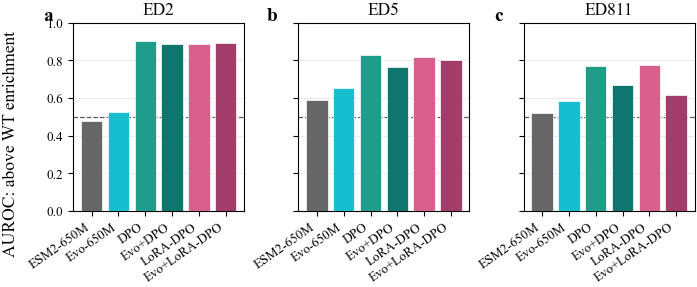

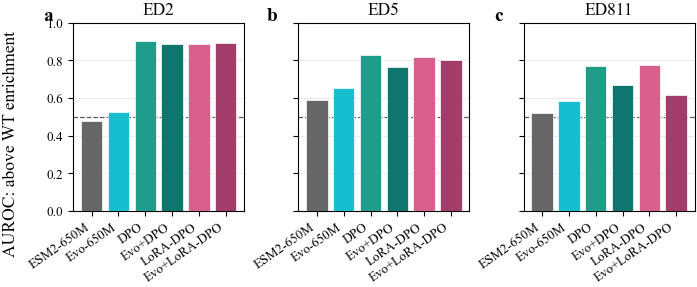

In [16]:
fig = render(report_figures.plot_all_models_auroc, 'dms_binding_auroc_all_models', 'functional')
fig

All report JSON artifacts are available.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\evotuning_heldout_spearman.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\evotuning_heldout_spearman.png


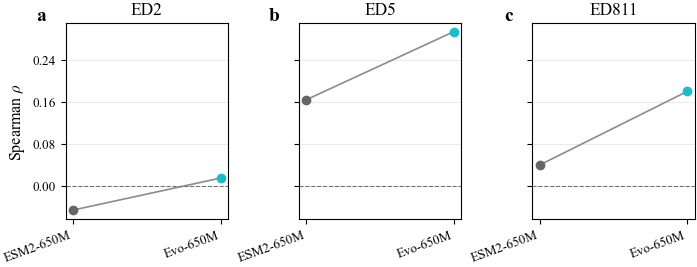

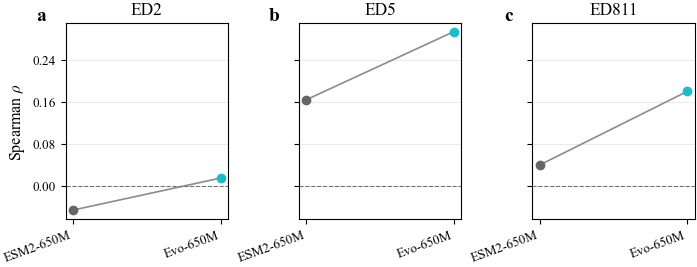

In [17]:
fig = render(report_figures.plot_evotune_functional, 'evotuning_heldout_spearman', 'functional')
fig

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\evotuning_cdr_pseudo_perplexity.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\evotuning_cdr_pseudo_perplexity.png


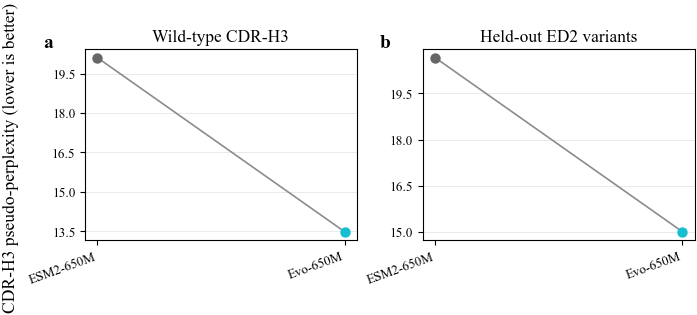

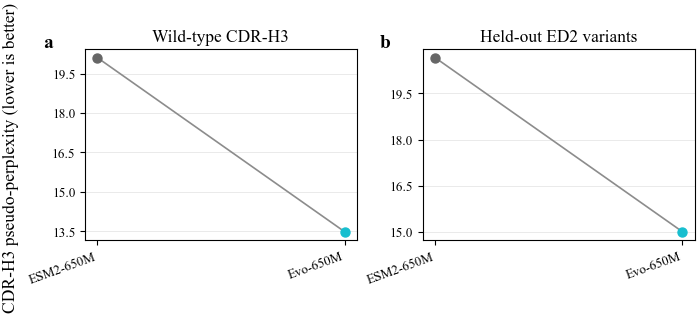

In [18]:
fig = render(report_figures.plot_cdr_pseudo_perplexity, 'evotuning_cdr_pseudo_perplexity', 'functional')
fig

## DPO: held-out preference learning

The artifact uses the original training summary only when all three requested metrics are present. Otherwise the Slurm collector recomputes the complete tuple from the checkpoint and its recovered evaluation configuration.

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dpo_heldout_preference_metrics.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dpo_heldout_preference_metrics.png


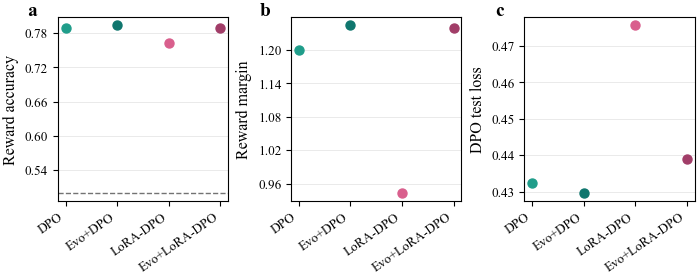

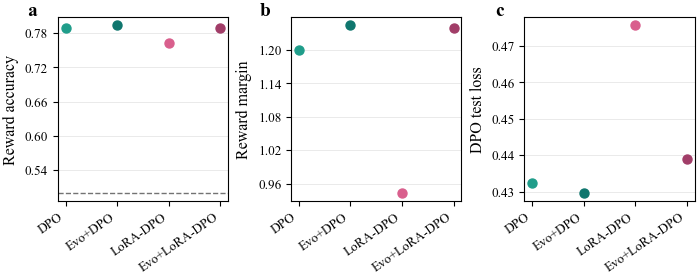

In [19]:
fig = render(report_figures.plot_preference_metrics, 'dpo_heldout_preference_metrics', 'preference')
fig

## Functional association and compact model table

ED2 is held out; ED5 and ED8Ã¢â‚¬â€œ11 are shown as out-of-distribution generalization panels. The paired model groups share the same y-axis scale.

All report JSON artifacts are available.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dpo_functional_association_by_base.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dpo_functional_association_by_base.png


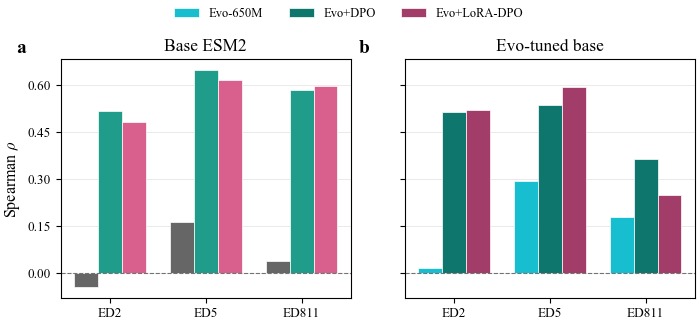

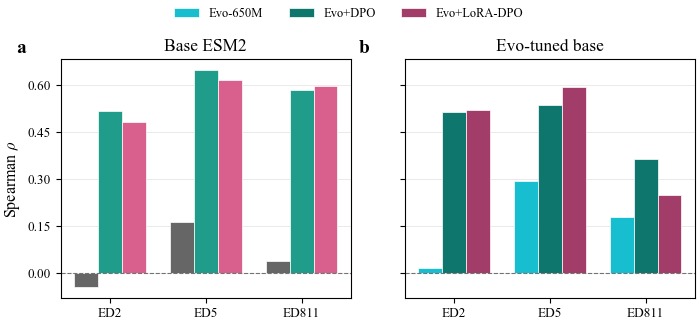

In [20]:
fig = render(lambda cfg: report_figures.plot_functional_groups(cfg, [['vanilla_650m', 'just_dpo_650m', 'just_lora_dpo_650m'], ['evo_650m', 'evo_dpo_650m', 'evo_lora_dpo_650m']], title=''), 'dpo_functional_association_by_base', 'functional')
fig

All report JSON artifacts are available.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dpo_functional_association_all_models.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dpo_functional_association_all_models.png


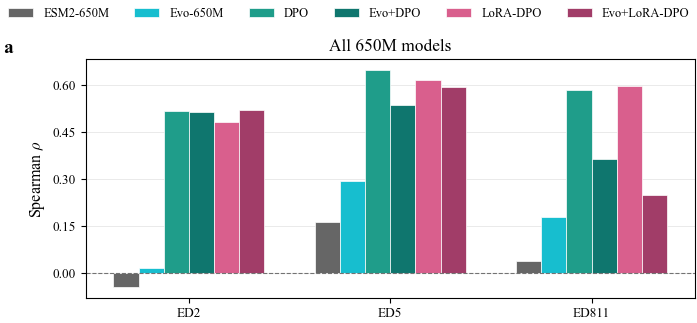

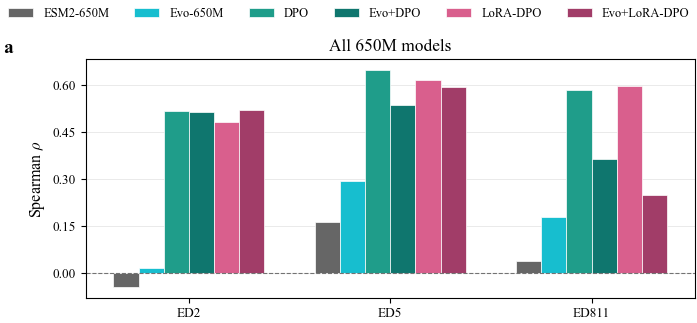

In [21]:
fig = render(report_figures.plot_all_models_functional, 'dpo_functional_association_all_models', 'functional')
fig

In [22]:
if report_figures.preflight(CONFIG, ['functional', 'preference']):
    table_path = None
else:
    table_path = report_figures.write_all_model_table(CONFIG, FIGURES_DIR)
    print(f'Wrote LaTeX table: {table_path}')
table_path

All report JSON artifacts are available.
Wrote LaTeX table: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\all_models_compact_summary_table.txt


WindowsPath('C:/Users/giogu/Desktop/ETH/Courses/2026_spring/Semestral/protein-design/report/figures/all_models_compact_summary_table.txt')

## Generation: quality, diversity, and sequence composition

Each model has a matched 5,000-sequence library for random, PSSM, Gibbs, and stochastic beam search. Native and common ESM2 likelihood views remain separate throughout.

All report JSON artifacts are available.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_quality_diversity_tradeoff.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_quality_diversity_tradeoff.png


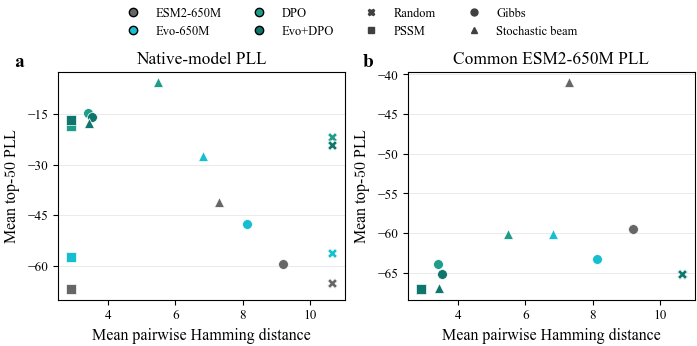

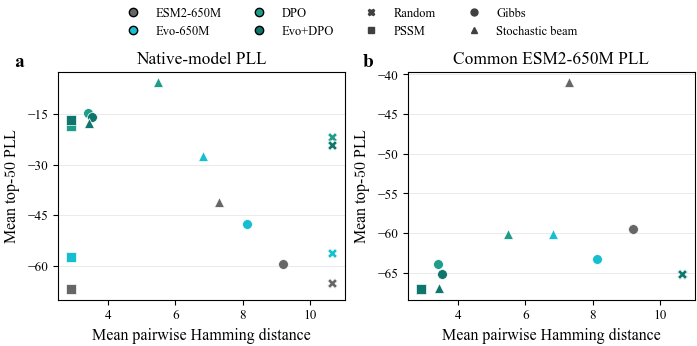

In [23]:
fig = render(report_figures.plot_generation_quality_diversity, 'generation_quality_diversity_tradeoff', 'generation')
fig

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_mutation_distance_by_model.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_mutation_distance_by_model.png


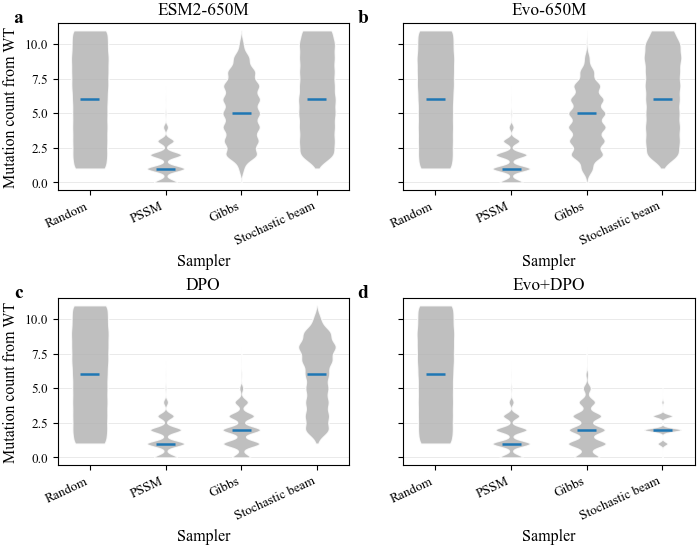

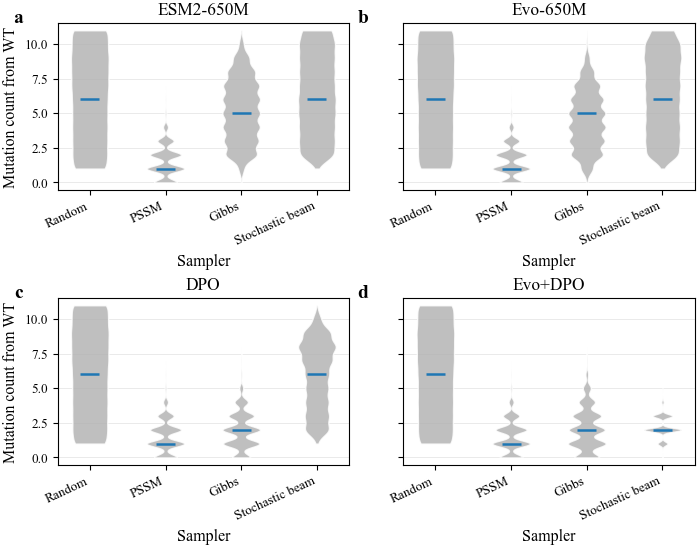

In [24]:
fig = render(report_figures.plot_generation_mutation_distance, 'generation_mutation_distance_by_model', 'generation')
fig

In [25]:
if report_figures.preflight(CONFIG, ["generation"]):
    table_paths = []
else:
    table_paths = [
        report_figures.write_generation_summary_table(CONFIG, evaluator, FIGURES_DIR)
        for evaluator in ["native", "common"]
    ]
    for table_path in table_paths:
        print(f"Wrote LaTeX table: {table_path}")

table_paths

All report JSON artifacts are available.
Wrote LaTeX table: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_library_summary_native_pll_table.txt
Wrote LaTeX table: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_library_summary_common_esm2_pll_table.txt


[WindowsPath('C:/Users/giogu/Desktop/ETH/Courses/2026_spring/Semestral/protein-design/report/figures/generation_library_summary_native_pll_table.txt'),
 WindowsPath('C:/Users/giogu/Desktop/ETH/Courses/2026_spring/Semestral/protein-design/report/figures/generation_library_summary_common_esm2_pll_table.txt')]

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_sequence_logos_native_pll.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_sequence_logos_native_pll.png


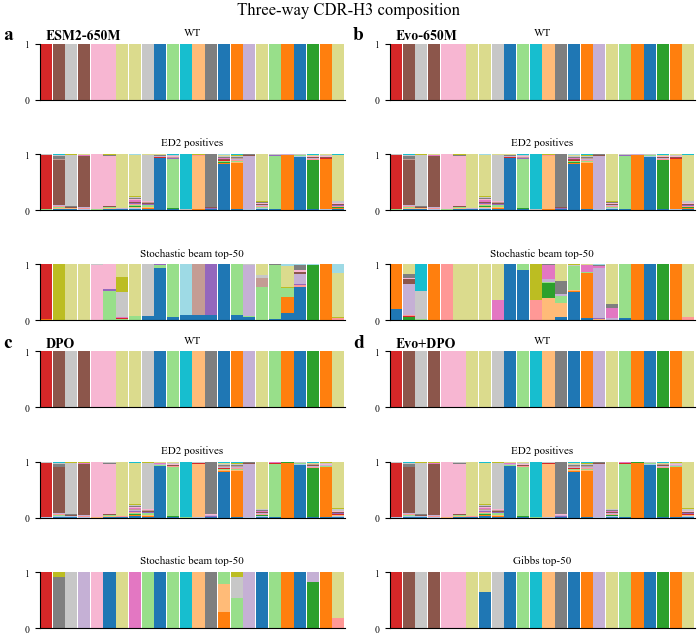

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_sequence_logos_common_esm2_pll.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_sequence_logos_common_esm2_pll.png


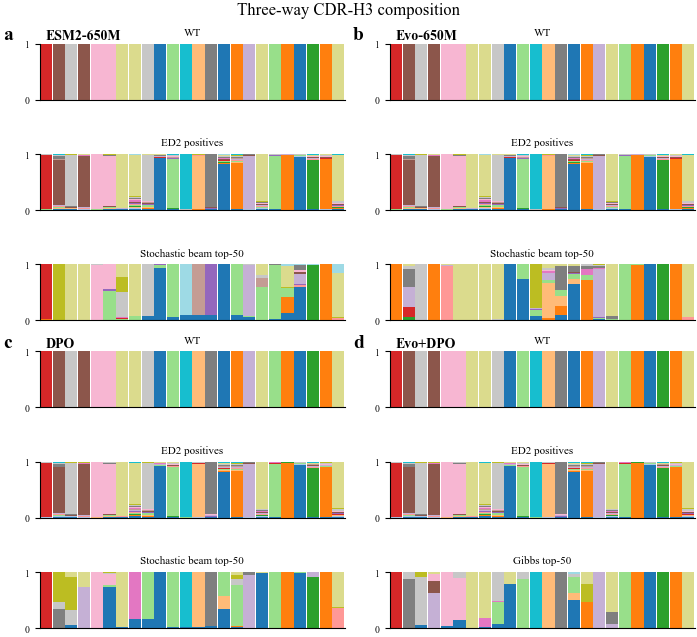

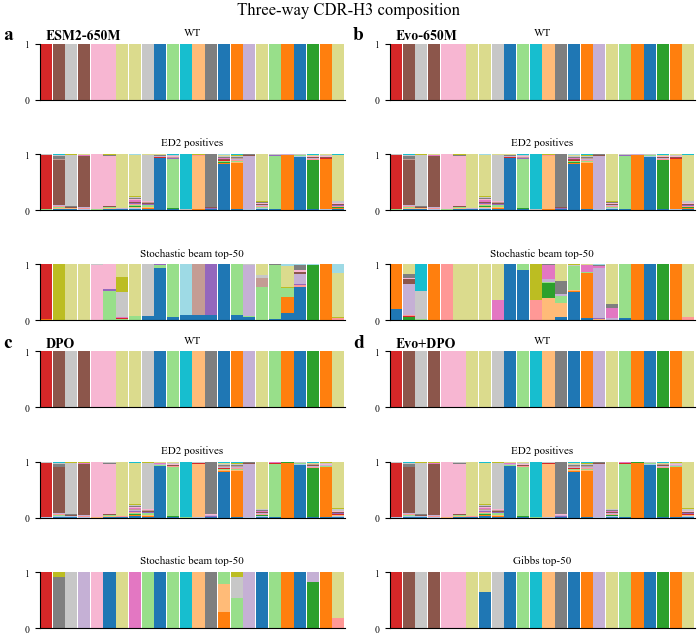

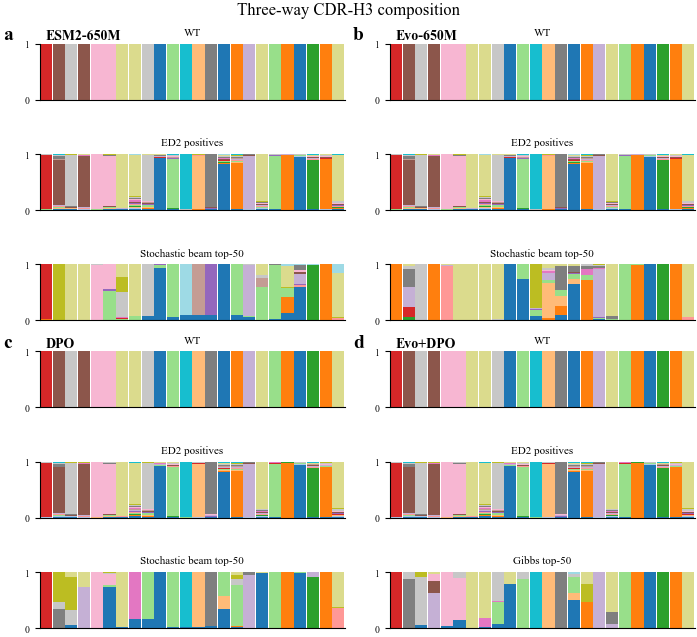

In [26]:
for evaluator, stem in [('native', 'generation_sequence_logos_native_pll'), ('common', 'generation_sequence_logos_common_esm2_pll')]:
    fig = render(lambda cfg, evaluator=evaluator: report_figures.plot_generation_logos(cfg, evaluator), stem, 'generation')
    if fig is not None:
        display(fig)

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_position_jsd_native_pll.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_position_jsd_native_pll.png


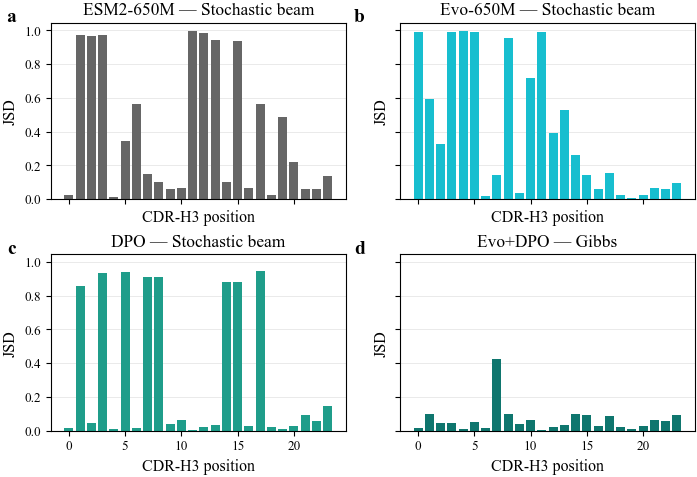

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_position_jsd_common_esm2_pll.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\generation_position_jsd_common_esm2_pll.png


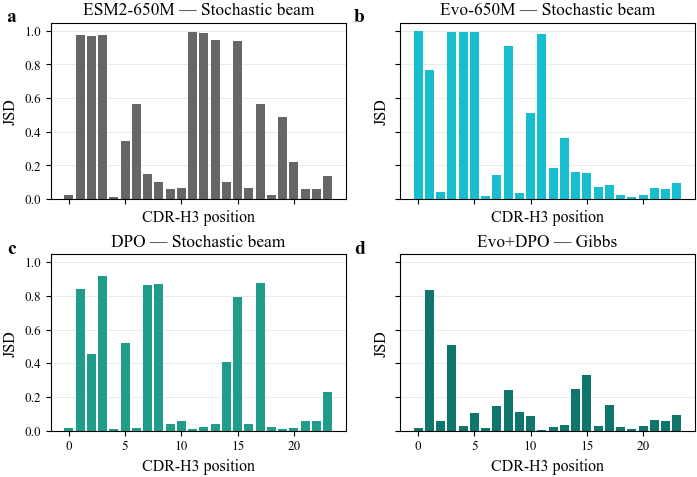

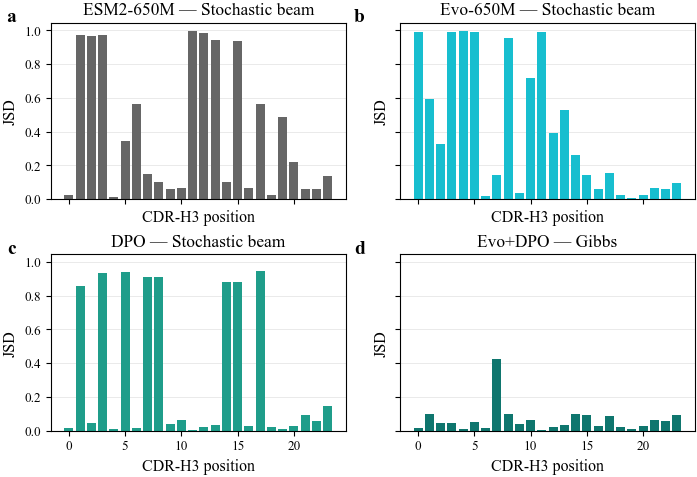

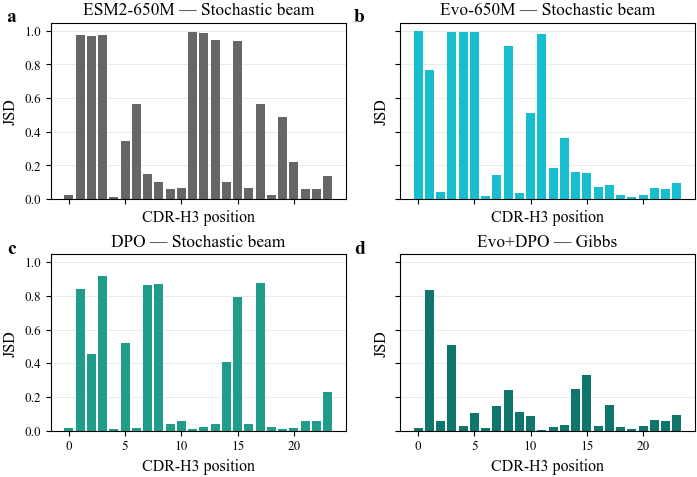

In [27]:
for evaluator, stem in [('native', 'generation_position_jsd_native_pll'), ('common', 'generation_position_jsd_common_esm2_pll')]:
    fig = render(lambda cfg, evaluator=evaluator: report_figures.plot_generation_jsd(cfg, evaluator), stem, 'generation')
    if fig is not None:
        display(fig)

## Held-out DMS binding-enrichment distributions

Matched Freedman–Diaconis density histograms use the same bins and axes across ED2, ED5, and ED8–11. The dashed line marks wild-type enrichment.

All report JSON artifacts are available.
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dms_binding_enrichment_distributions.pdf
Saved: C:\Users\giogu\Desktop\ETH\Courses\2026_spring\Semestral\protein-design\report\figures\dms_binding_enrichment_distributions.png


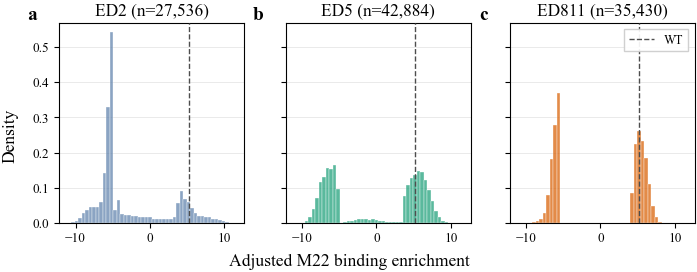

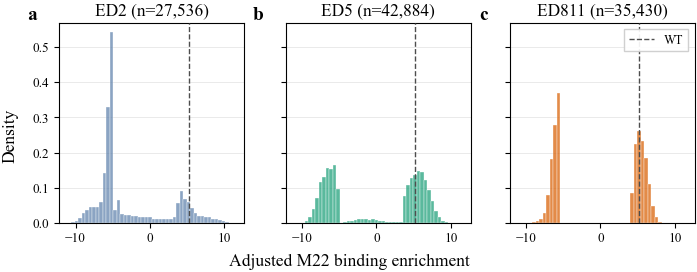

In [28]:
fig = render(report_figures.plot_dms_binding_enrichment_distributions, 'dms_binding_enrichment_distributions', 'dms_distribution')
fig

## Visual QA

Inspect both formats before committing a figure: labels must be readable at paper scale, model colours must remain stable, legends must not cover data, and PDF text/axes should remain vector.